# Күрделі архитектуралар
### Автокодерлер (VAE), генеративті қарсыластар желілері (GAN), трансформерлер (self-attention, multi-head attention)

## 1️⃣ Теоретические задачи
Эти задачи помогают понять, как VAE работает на уровне концепций и формул.

### 1. Энкодер и декодер

Объясните своими словами, чем VAE отличается от обычного автоэнкодера.

Почему в VAE вместо прямого кодирования в z мы используем распределение q(z|x)?


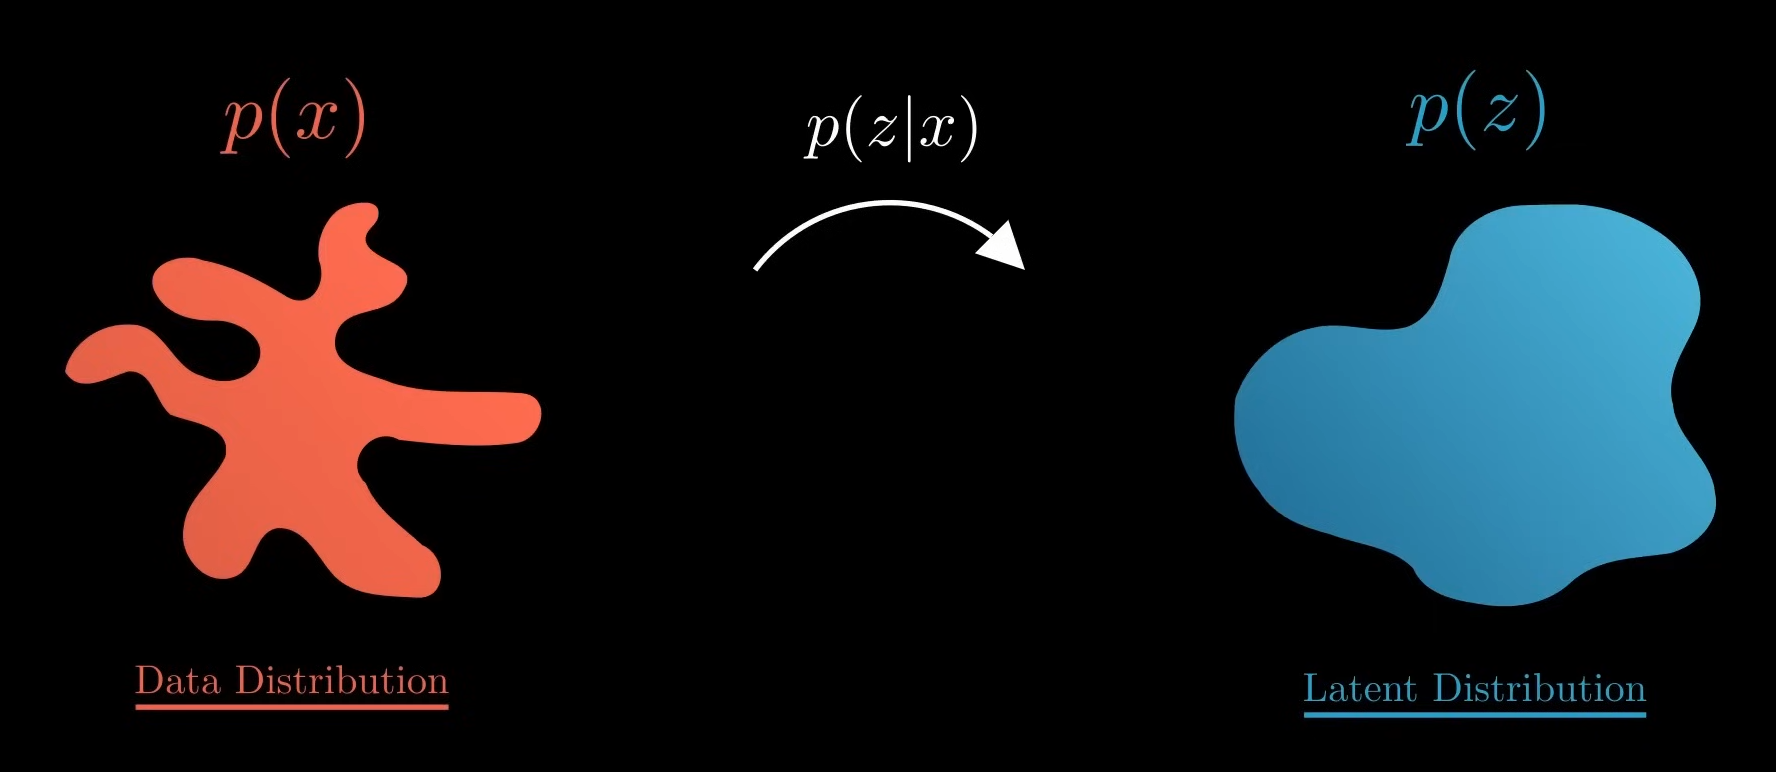
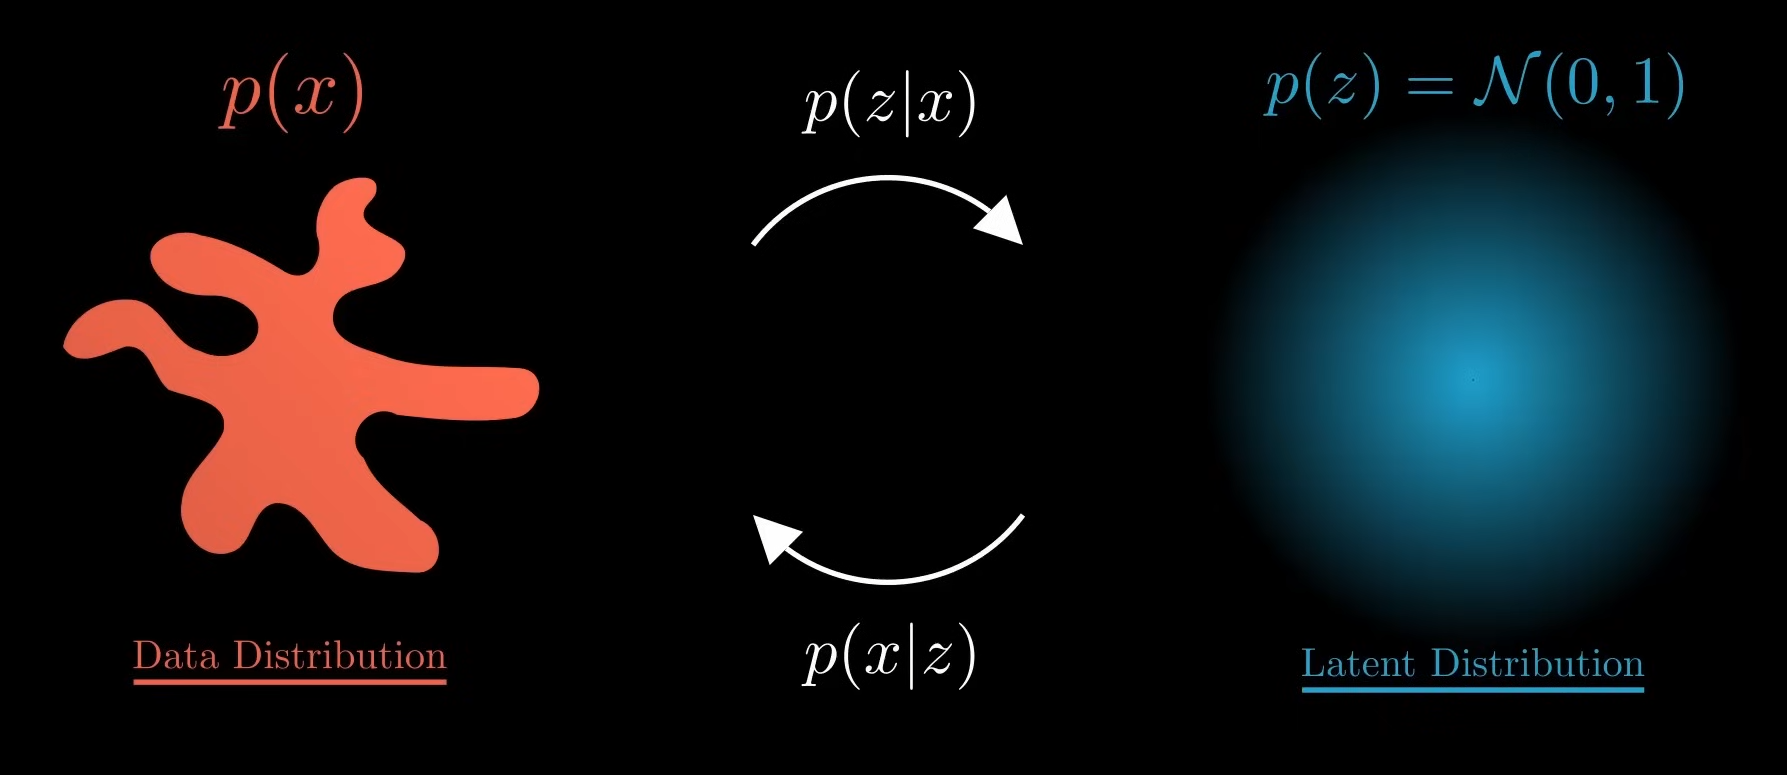
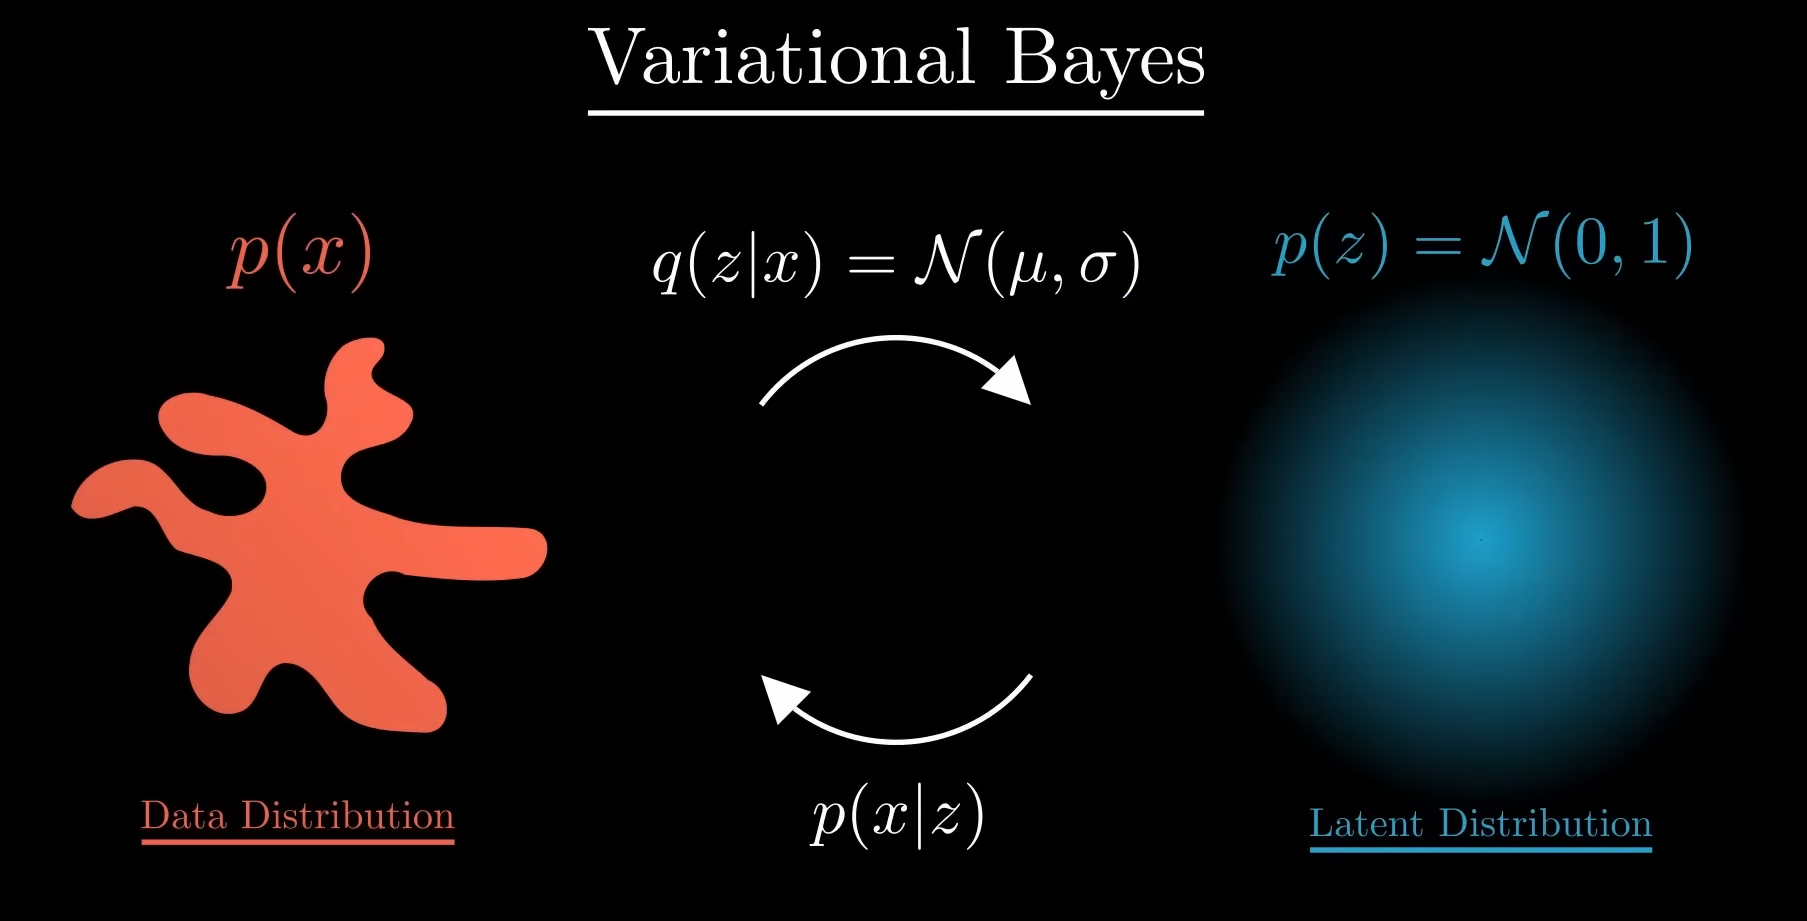

### 2. Распределение латентного пространства


Допустим, латентное пространство двумерное. Нарисуйте, как распределение z должно выглядеть для нормального распределения N(0,1) и что происходит, если энкодер сильно отклоняется от этого распределения.

Объясните роль KL-дивергенции в VAE. Почему мы минимизируем её между q(z|x) и p(z)?




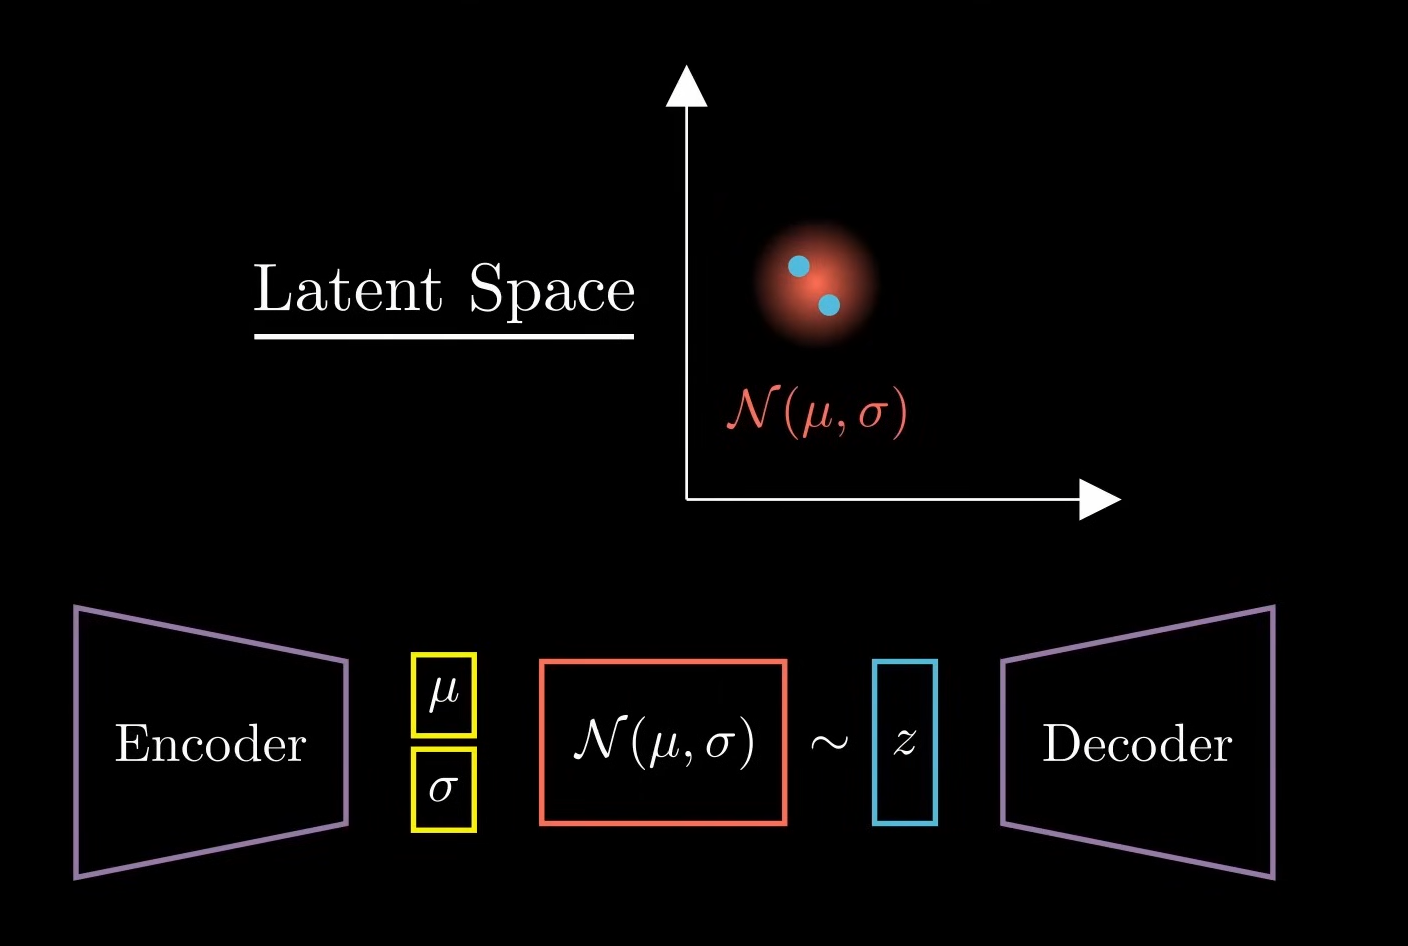

Математикалық тұрғыдан бұл бір ықтималдық үлестірімінің ($q$) екіншісінен ($p$) қаншалықты ерекшеленетіндігінің өлшемі. Vae контекстінде:

- $q(z|x)$ — бұл біздің кодер белгілі бір кіру үшін беретін тарату.

- $p(z)$ — бұл **априорлық (prior)** үлестіру, әдетте стандартты қалыпты $\mathcal{N} (0, 1)$.

### 3. Функция потерь

Разделите ELBO (Evidence Lower Bound) на две части и объясните каждую:

- Reconstruction loss

- KL-divergence loss

Что будет, если мы полностью уберём KL-дивергенцию? Как это повлияет на латентное пространство?


<img src='VAE_architecture_infographic.png'>

## 2️⃣ Практические задачи
Эти задачи помогают закрепить понимание VAE через код и визуализацию.


### ***The basic structure of any model in PyTorch**

In [32]:
import torch 
import torch.nn as nn 

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(10, 20) 
        self.layer2 = nn.ReLU()
        self.layer3 = nn.Linear(20, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x 

### 1. Реализация VAE на MNIST

Постройте маленький VAE на датасете MNIST (28×28 изображения).

Энкодер → двумерное латентное пространство.

Декодер → восстановление изображения.

Визуализируйте латентное пространство (scatter plot латентных переменных для разных цифр).


### Import libraries & Setup 

In [ ]:
import torch 
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt 
import numpy as np 

from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

latent_dim = 2

Device: cuda


In [2]:
# Download training data from open datasets
training_data = datasets.MNIST(root='data', train=True, download=True, transform=ToTensor())

# Download test data from open datasets
test_data = datasets.MNIST(root='data', train=False, download=True, transform=ToTensor())

In [3]:
batch_size = 64 

# Create data Loaders
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64])


In [ ]:
# !pip install torchsummary

In [4]:
from torchsummary import summary

In [ ]:
# Define model
class VAE(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Encoder 
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder 
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h) 
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
     
    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))
    
    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar 

In [6]:
def loss_function(recon_x, x, mu, logvar):
    BCE  = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD 


In [7]:
def plot_latent_space(model, data_loader):
    model.eval()
    latents = []
    labels = []
    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            mu, _ = model.encode(data.view(-1, 784))
            latents.append(mu.cpu())
            labels.append(target)
    
    latents = torch.cat(latents, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()

    plt.figure(figsize=(10, 8))
    plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.5)
    plt.colorbar()
    plt.title("2D Latent Space (MNIST)")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.show()

torch.Size([64, 1, 28, 28])


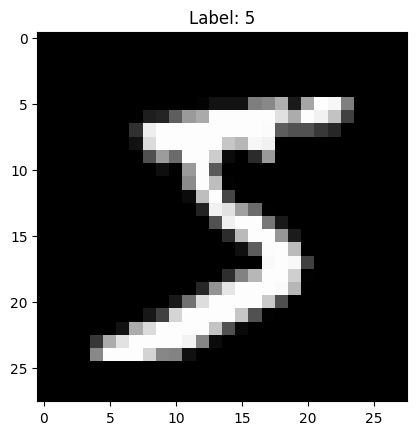

In [ ]:
images, labels = next(iter(train_dataloader))

print(images.shape) 

plt.imshow(images[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [13]:
model = VAE().to(device)

model_summary = summary(model, input_size=(1, 784))
print(f"Model summary: {model_summary}\n")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 400]         314,000
            Linear-2                    [-1, 2]             802
            Linear-3                    [-1, 2]             802
            Linear-4                  [-1, 400]           1,200
            Linear-5                  [-1, 784]         314,384
Total params: 631,188
Trainable params: 631,188
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.41
Estimated Total Size (MB): 2.42
----------------------------------------------------------------
Model summary: None



In [ ]:
def train(epoch):
    model.train() 
    train_loss = 0
    
    for batch_idx, (data, _) in enumerate(train_dataloader):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # PyTorch строит граф вычислений и считает производную (градиент) для каждого веса.
        loss.backward()
        
        # 6. Step (Обновление весов)
        # Оптимизатор меняет веса модели, используя посчитанные градиенты.
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_dataloader.dataset):.4f}')

# Запуск на 5 эпох
for epoch in range(1, 6):
    train(epoch)

====> Epoch: 1 Average loss: 182.2993
====> Epoch: 2 Average loss: 166.3965
====> Epoch: 3 Average loss: 163.2194
====> Epoch: 4 Average loss: 161.0415
====> Epoch: 5 Average loss: 159.3732


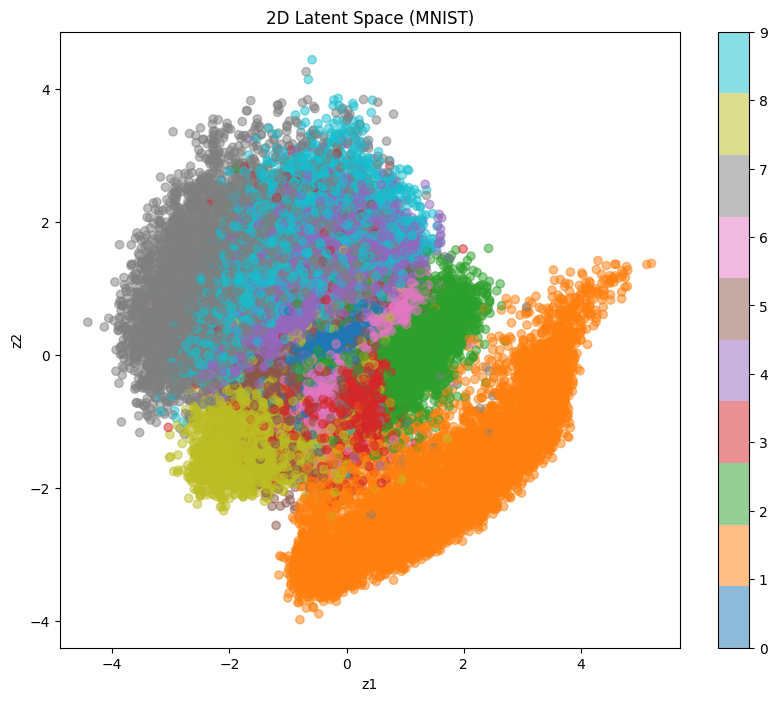

In [44]:
plot_latent_space(model, data_loader=train_dataloader)

In [16]:
model_summary = summary(model, input_size=(1, 784))
print(f"Model summary: {model_summary}\n")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 400]         314,000
            Linear-2                    [-1, 2]             802
            Linear-3                    [-1, 2]             802
            Linear-4                  [-1, 400]           1,200
            Linear-5                  [-1, 784]         314,384
Total params: 631,188
Trainable params: 631,188
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.41
Estimated Total Size (MB): 2.42
----------------------------------------------------------------
Model summary: None



In [ ]:
# VAE оқыту
model_vae.train()
for epoch in range(num_epochs):
    train_loss = 0
    for data in dataloader:
        img, _ = data
        img = img.to(device)

        optimizer_vae.zero_grad()
        recon_batch, mu, logvar = model_vae(img)

        loss = loss_function_vae(recon_batch, img, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer_vae.step()

    print(f'VAE Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss / len(dataloader.dataset):.4f}')

# Генерация нәтижесін визуализациялау
model_vae.eval()
with torch.no_grad():
    # Латентті кеңістіктен кездейсоқ вектор алу
    z = torch.randn(64, 20).to(device)
    sample = model_vae.decode(z).cpu()

    # Сурет салу
    plt.figure(figsize=(8, 8))
    plt.scatter(z[:, 0].cpu(), z[:, 1].cpu(), c=my_color, alpha=0.7, edgecolors='white')
    plt.title("Латентті кеңістіктің (Latent Space) шартты көрінісі", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.show()

    print("Генерацияланған суреттер мысалы:")
    plt.figure(figsize=(5, 5))
    plt.imshow(sample[0].view(28, 28), cmap='gray')
    plt.title("VAE арқылы жасалған цифр", color=my_color)
    plt.axis('off')
    plt.show()

### 2. Генерация новых примеров


Сэмплируйте точки из N(0,1) в латентном пространстве и пропустите через декодер.

Сравните с оригинальными изображениями.


### 3. Влияние KL-дивергенции

Попробуйте уменьшить или увеличить коэффициент KL loss (β-VAE).

Посмотрите, как меняется качество генерации и структура латентного пространства.




## 3️⃣ Более глубокие задачи
Для закрепления интуиции и понимания принципов вариационного вывода.

### 1. Интерполяции в латентном пространстве


Выберите два изображения из датасета.

Пропустите их через энкодер → получите два z.

Постройте линейную интерполяцию между ними в латентном пространстве и пропустите через декодер.

Объясните, почему интерполяция выглядит плавно (или нет).




### 2. Анализ распределений


Постройте гистограмму латентных переменных для всего датасета.


Проверяйте, насколько они близки к N(0,1).


### 3. Применение VAE к аномалиям


Обучите VAE на нормальных данных.


Попробуйте восстановить аномальные примеры.


Используйте reconstruction loss для выявления аномалий.


